In [2]:
!mkdir -p fonts
!wget -q https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf \
-O fonts/NanumGothic.ttf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('fonts/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(13) # 숙제 번호 13을 시드로 (재현 가능성)
N = 150
genre = rng.choice(['뉴스', '소설', '대화', '학술'], size=N, p=[0.3, 0.3, 0.2, 0.2])
base = {'뉴스': 22, '소설': 18, '대화': 9, '학술': 28} # 장르별 평균 어절 수
words = (np.array([base[g] for g in genre]) + rng.normal(0, 5, N)).clip(3, 60)
words = words.round().astype(int)
syllables = (words * 2.5 + rng.normal(0, 4, N)).clip(5, None).round().astype(int)
read_time = (syllables * 0.35 + rng.normal(0, 1.5, N)).clip(1, None).round(1)
difficulty = (words * 0.15 + rng.normal(0, 1.2, N)).clip(1, 10).round(1)
texts = pd.DataFrame({
    '장르': genre,
    '어절수': words,
    '음절수': syllables,
    '읽기시간': read_time,
    '난이도': difficulty,
})

# 연도별 신문/소설의 외래어 비율(%) (가상 데이터)
trends = pd.DataFrame({
    '연도': [1990, 1995, 2000, 2005, 2010, 2015, 2020],
    '뉴스': [5.1, 6.3, 8.0, 9.4, 11.2, 13.5, 15.1],
    '소설': [3.2, 3.5, 4.0, 4.6, 5.1, 5.8, 6.4],
})



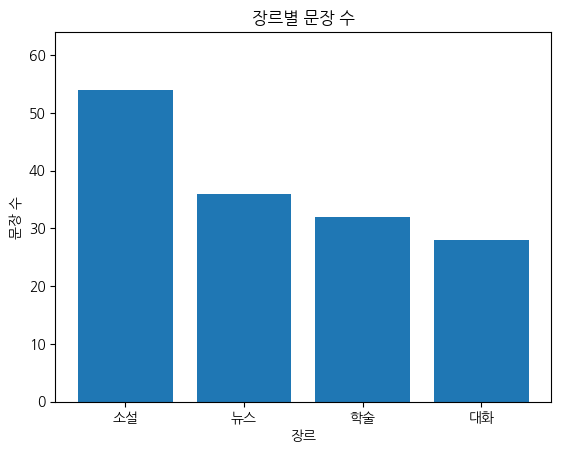

In [4]:
# Q1 
# (a) - (1)
def plot_genre_bar(texts: pd.DataFrame) -> None:
    genre_counts = texts['장르'].value_counts()
    fig, ax = plt.subplots()
    ax.bar(genre_counts.index, genre_counts.values)
    ax.set_title('장르별 문장 수')
    ax.set_xlabel('장르')
    ax.set_ylabel('문장 수')
    ax.set_ylim(0, genre_counts.max() + 10)
    plt.show()

plot_genre_bar(texts)

(a) - (2)
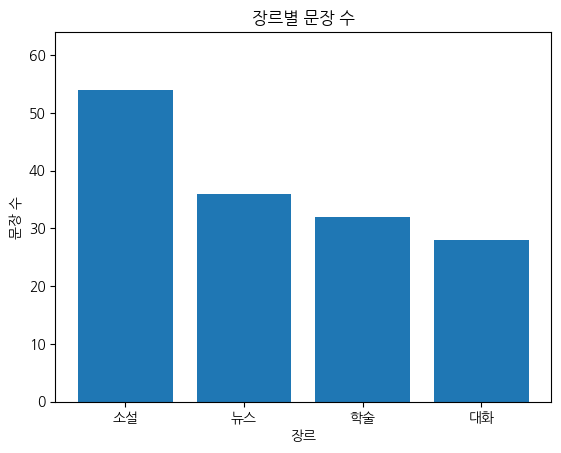
(a) - (3)
texts['장르'].value_counts()로 장르별 빈도를 집계한 뒤 ax.bar()에 인덱스(장르명)와 값(빈도)을 넘겨 막대 그래프를 그렸다. set_ylim(0, ...)으로 y축을 명시적으로 0부터 시작시켜 막대 길이가 실제 비율을 정확히 반영하도록 하였다.


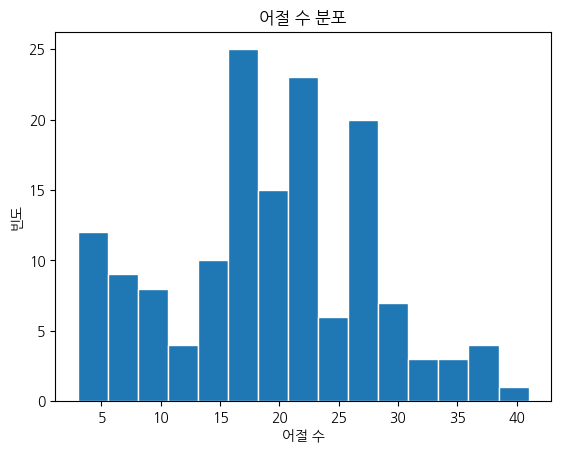

In [5]:
# (b) - (1)
def plot_word_hist(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.hist(texts['어절수'], bins=15, edgecolor='white')
    ax.set_title('어절 수 분포')
    ax.set_xlabel('어절 수')
    ax.set_ylabel('빈도')
    plt.show()

plot_word_hist(texts)

(b) - (2)
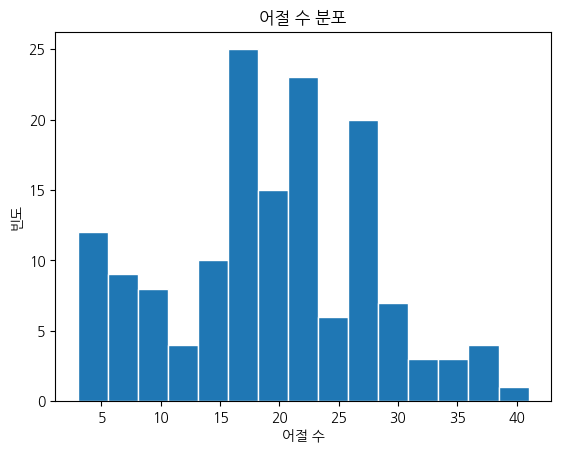
(b) - (3)
ax.hist()에 bins=15로 구간 수를 지정하여 어절 수의 도수분포를 시각화하였다. edgecolor='white'를 주어 인접한 막대 사이의 경계를 명확히 구분하였다
관찰: 어절 수는 주로 10–25 구간에 집중되어 있다.

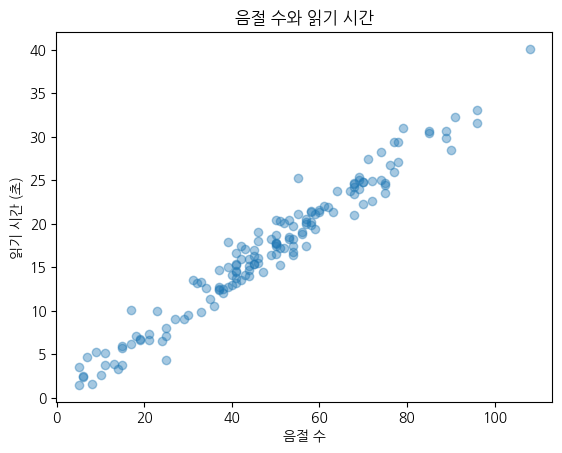

In [6]:
# (c) - (1)
def plot_syllable_time(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
    ax.set_title('음절 수와 읽기 시간')
    ax.set_xlabel('음절 수')
    ax.set_ylabel('읽기 시간 (초)')
    plt.show()

plot_syllable_time(texts)

(c) - (2)
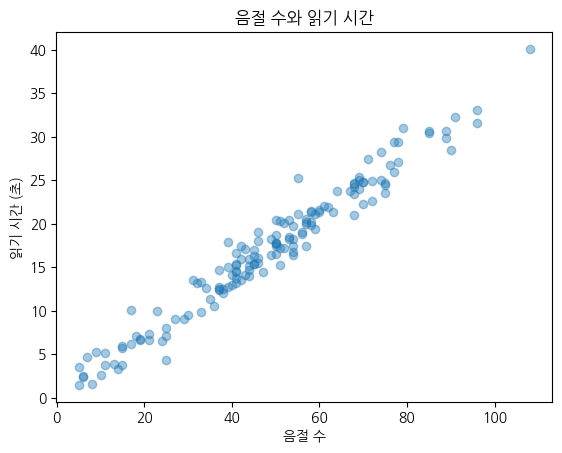
(c) - (3)
ax.scatter()로 음절수(x)와 읽기시간(y)을 점으로 표현하였다. 데이터 포인트가 겹치는 구간에서도 밀도를 확인할 수 있도록 alpha=0.4로 투명도를 조절하였다.
관찰: 음절 수와 읽기 시간은 우상향 관계를 보인다.

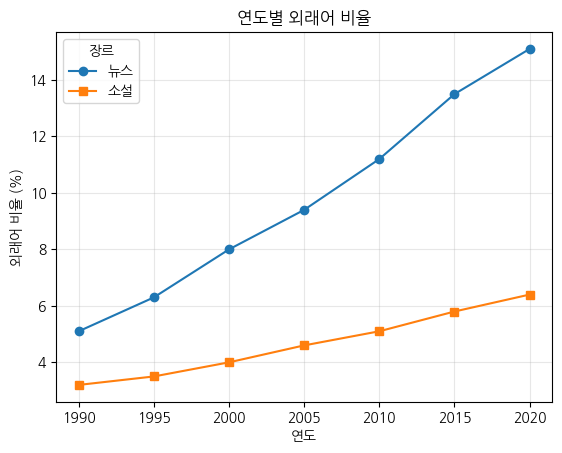

In [7]:
# Q2
# (a) - (1)
def plot_loanword_trend(trends: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    ax.plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    ax.plot(trends['연도'], trends['소설'], marker='s', label='소설')
    ax.legend(title='장르')
    ax.grid(True, alpha=0.3)
    ax.set_title('연도별 외래어 비율')
    ax.set_xlabel('연도')
    ax.set_ylabel('외래어 비율 (%)')
    plt.show()

plot_loanword_trend(trends)

(a) - (2)
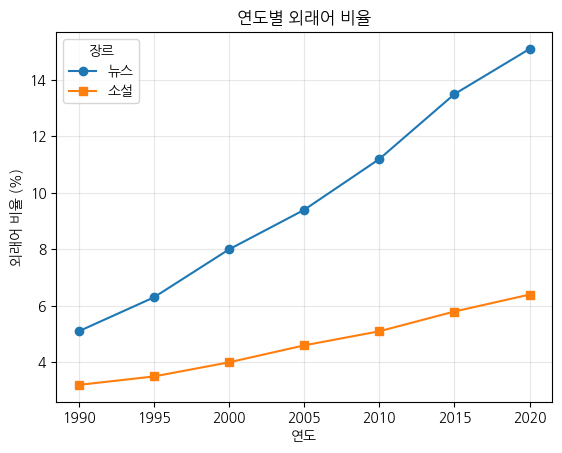
(a) - (3)
ax.plot()을 두 번 호출하여 뉴스와 소설 두 계열을 같은 Axes에 겹쳐 그렸다. 각 선에 marker와 label을 지정한 뒤 ax.legend(title='장르')로 범례를 표시하였고, ax.grid(True, alpha=0.3)으로 값을 읽기 쉽도록 옅은 격자를 추가하였다.
관찰: 두 장르 모두 외래어 비율이 증가하고 있으나 뉴스의 증가 폭이 소설보다 훨씬 커서 시간이 갈수록 격차가 벌어진다.

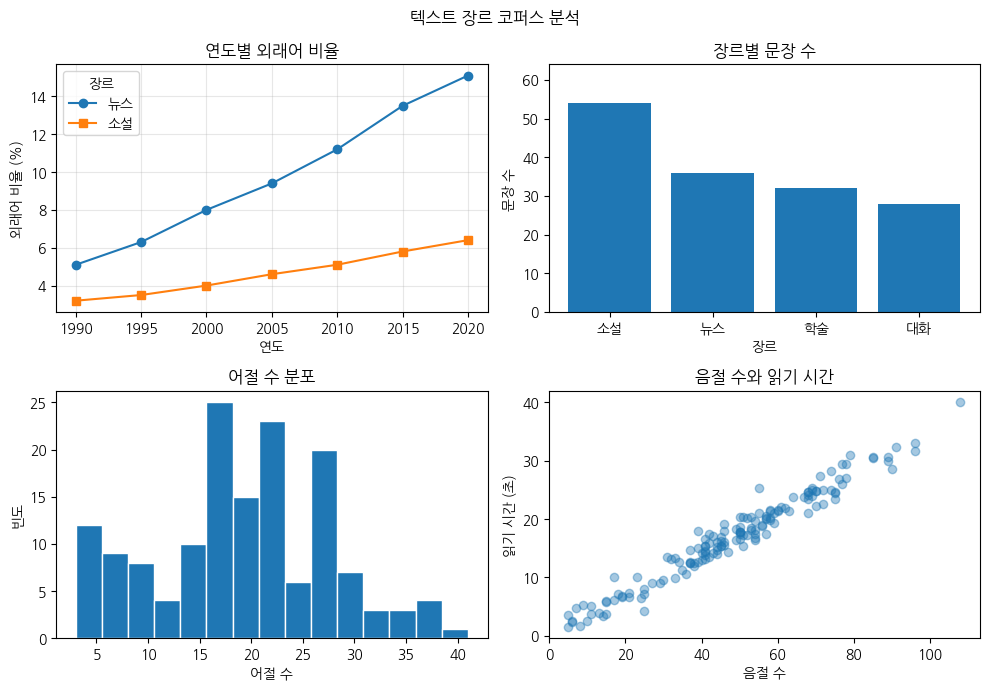

In [8]:
# (b) - (1)
def plot_subplots(texts: pd.DataFrame, trends: pd.DataFrame) -> None:
    genre_counts = texts['장르'].value_counts()
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))

    # [0, 0]: 선 그래프
    axes[0, 0].plot(trends['연도'], trends['뉴스'], marker='o', label='뉴스')
    axes[0, 0].plot(trends['연도'], trends['소설'], marker='s', label='소설')
    axes[0, 0].legend(title='장르')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_title('연도별 외래어 비율')
    axes[0, 0].set_xlabel('연도')
    axes[0, 0].set_ylabel('외래어 비율 (%)')

    # [0, 1]: 막대 그래프
    axes[0, 1].bar(genre_counts.index, genre_counts.values)
    axes[0, 1].set_title('장르별 문장 수')
    axes[0, 1].set_xlabel('장르')
    axes[0, 1].set_ylabel('문장 수')
    axes[0, 1].set_ylim(0, genre_counts.max() + 10)

    # [1, 0]: 히스토그램
    axes[1, 0].hist(texts['어절수'], bins=15, edgecolor='white')
    axes[1, 0].set_title('어절 수 분포')
    axes[1, 0].set_xlabel('어절 수')
    axes[1, 0].set_ylabel('빈도')

    # [1, 1]: 산점도
    axes[1, 1].scatter(texts['음절수'], texts['읽기시간'], alpha=0.4)
    axes[1, 1].set_title('음절 수와 읽기 시간')
    axes[1, 1].set_xlabel('음절 수')
    axes[1, 1].set_ylabel('읽기 시간 (초)')

    fig.suptitle('텍스트 장르 코퍼스 분석')
    fig.tight_layout()
    fig.savefig('hw13_subplots.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_subplots(texts, trends)

(b) - (2)
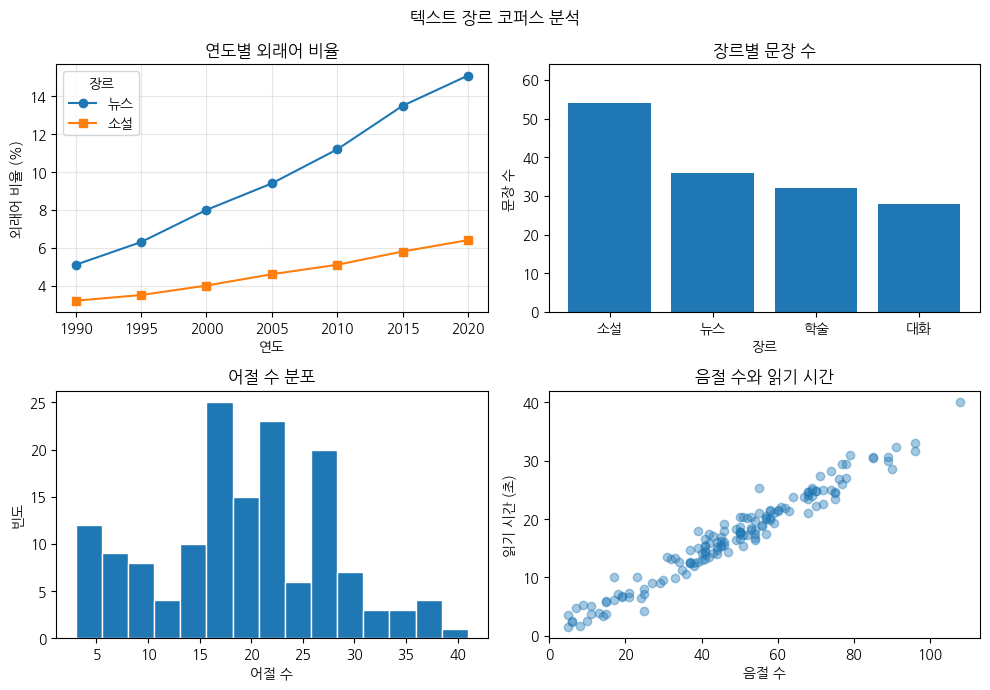
(b) - (3)
plt.subplots(2, 2, figsize=(10, 7))로 2×2 격자를 생성하고, 앞서 작성한 네 그래프를 각 axes[i, j]에 배치하였다. fig.suptitle()로 전체 제목을 달고, fig.tight_layout()으로 서브플롯 간 겹침을 방지한 뒤 fig.savefig()로 PNG 파일로 저장하였다.

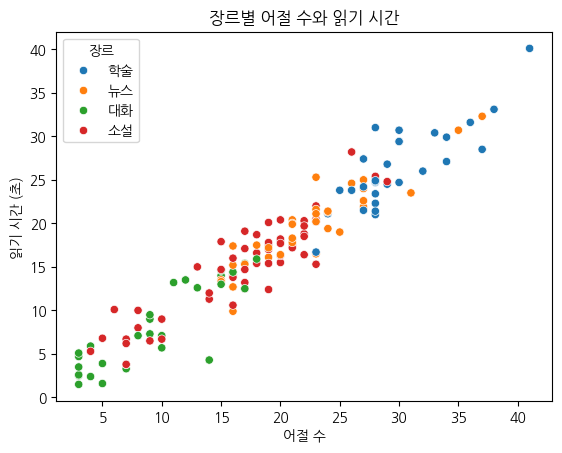

In [10]:
# Q3
# (a) - (1)
import seaborn as sns

def plot_sns_scatter(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    sns.scatterplot(data=texts, x='어절수', y='읽기시간', hue='장르', ax=ax)
    ax.set_title('장르별 어절 수와 읽기 시간')
    ax.set_xlabel('어절 수')
    ax.set_ylabel('읽기 시간 (초)')
    plt.show()

plot_sns_scatter(texts)

(a) - (2)
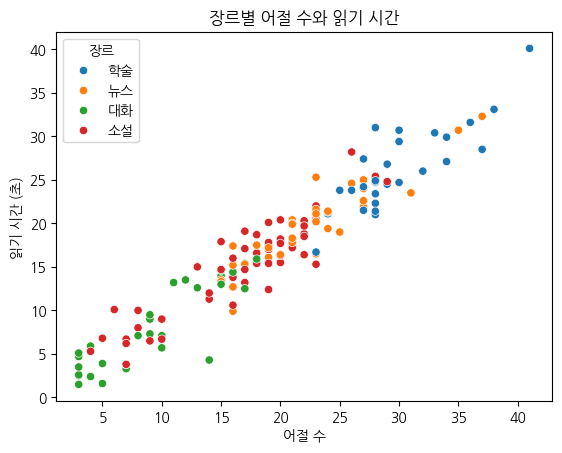
(a) - (3)
sns.scatterplot()의 hue='장르' 인자를 통해 seaborn이 장르별로 색상을 자동 배분하도록 하였다. fig, ax = plt.subplots()로 생성한 Axes를 ax=ax로 연동하여 객체지향 방식을 유지하였다.

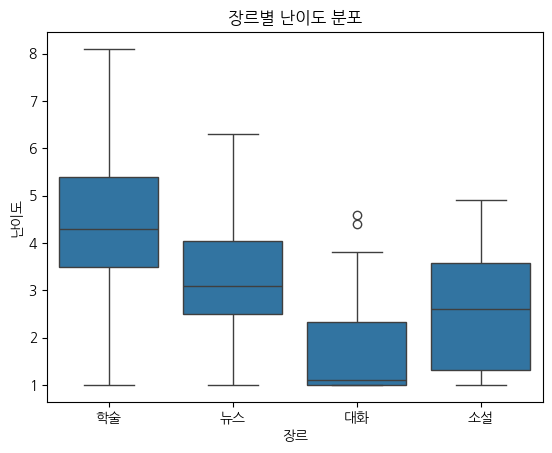

In [11]:
# (b) - (1)
def plot_difficulty_box(texts: pd.DataFrame) -> None:
    fig, ax = plt.subplots()
    sns.boxplot(data=texts, x='장르', y='난이도', ax=ax)
    ax.set_title('장르별 난이도 분포')
    ax.set_xlabel('장르')
    ax.set_ylabel('난이도')
    plt.show()

plot_difficulty_box(texts)

(b) - (2)
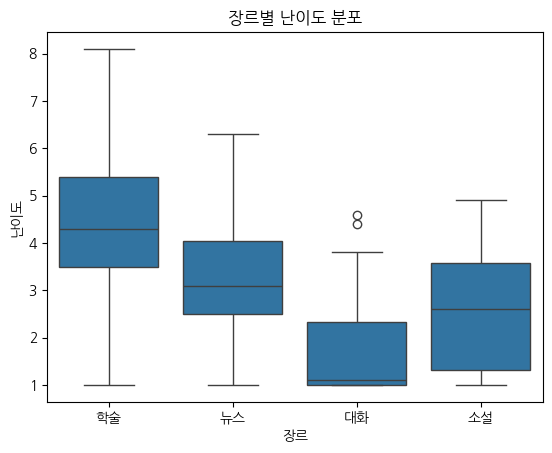
(b) - (3)
sns.boxplot()으로 장르(x)별 난이도(y)의 분포를 중앙값·IQR·이상치 포함 상자그림으로 나타냈다. ax=ax로 미리 만든 Axes에 연동하여 제목과 축 이름을 일관된 방식으로 지정하였다.
관찰: 난이도가 가장 높은 장르는 학술이며, 상자의 크기(IQR)가 가장 큰 장르는 소설이다.

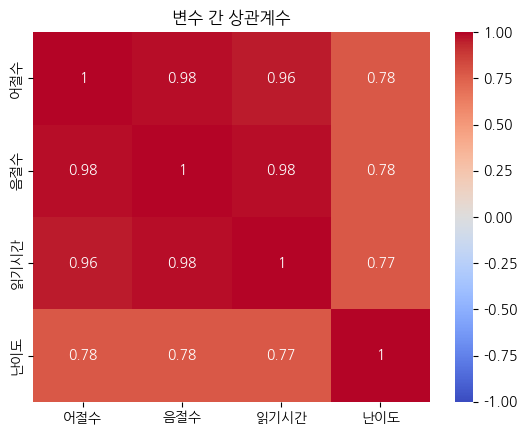

In [12]:
# (c) - (1)
def plot_corr_heatmap(texts: pd.DataFrame) -> None:
    corr = texts[['어절수', '음절수', '읽기시간', '난이도']].corr()
    fig, ax = plt.subplots()
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
    ax.set_title('변수 간 상관계수')
    plt.show()

plot_corr_heatmap(texts)

(c) - (2)
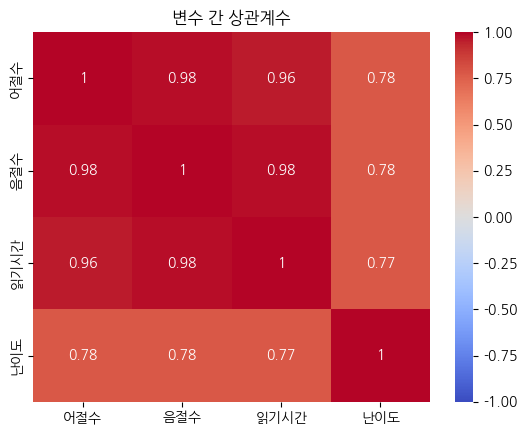
(c) - (3)
texts[['어절수', '음절수', '읽기시간', '난이도']].corr()로 네 변수의 피어슨 상관계수 행렬을 구한 뒤 sns.heatmap()으로 시각화하였다. annot=True로 각 셀에 수치를 표시하고, cmap='coolwarm'과 vmin=-1, vmax=1로 색상 범위를 상관계수의 이론적 범위에 고정하였다.
 관찰: 서로 가장 강하게 함께 증가하는 두 변수는 음절수와 읽기시간(r ≈ 0.98)이다. 읽기 시간이 음절 수에 비례하여 산출되었기 때문에 두 변수 사이에 거의 선형에 가까운 강한 양의 상관이 나타난다.

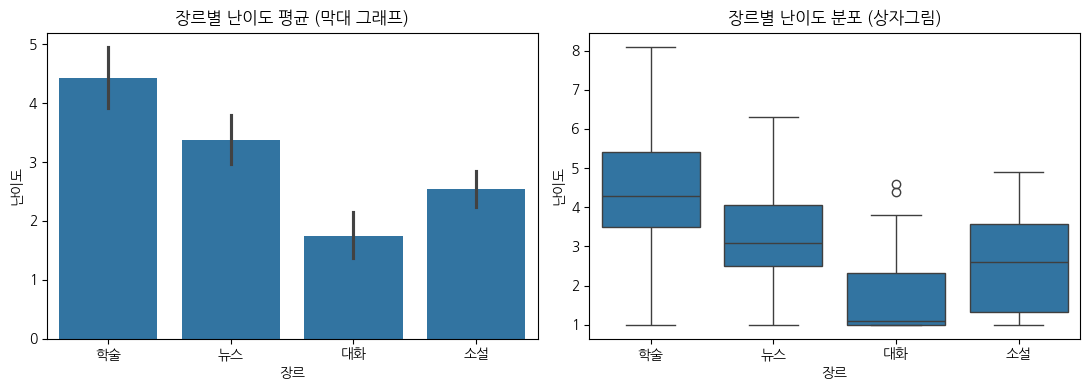

In [13]:
# Q4
# (a) - (1)
def plot_honest_comparison(texts: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    sns.barplot(data=texts, x='장르', y='난이도', ax=axes[0])
    axes[0].set_title('장르별 난이도 평균 (막대 그래프)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('난이도')

    sns.boxplot(data=texts, x='장르', y='난이도', ax=axes[1])
    axes[1].set_title('장르별 난이도 분포 (상자그림)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('난이도')

    fig.tight_layout()
    plt.show()

plot_honest_comparison(texts)

(a) - (2)
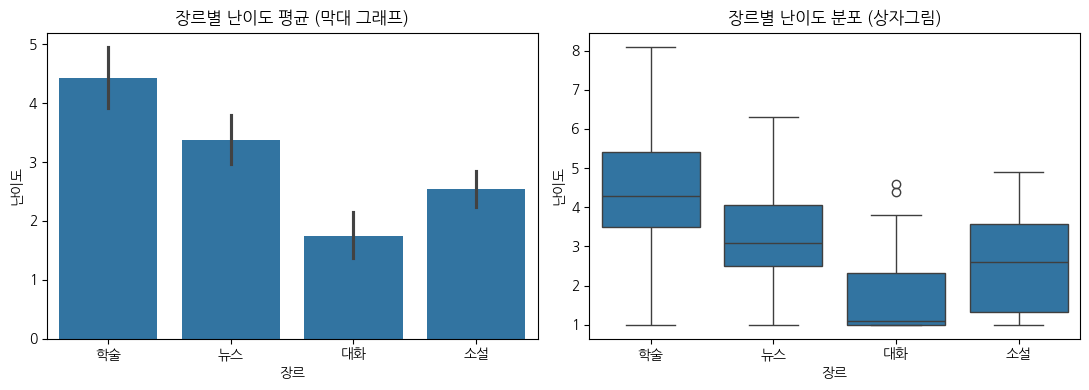
(a) - (3)
sns.barplot()은 기본적으로 평균과 신뢰구간만 표시하므로 분포의 형태를 알 수 없다. 오른쪽에 sns.boxplot()을 나란히 배치하여 같은 데이터에서 평균 외에 중앙값·IQR·이상치까지 드러나도록 대비하였다.
서술: 왼쪽 막대 그래프는 장르별 평균값만 보여 주므로 분포의 퍼짐, 중앙값의 위치, 이상치 유무를 전혀 알 수 없다. 예를 들어 뉴스와 소설의 평균 난이도가 비슷하더라도 뉴스는 좁고 일관된 분포, 소설은 넓고 불균일한 분포일 수 있는데 막대 그래프는 이 차이를 완전히 숨긴다.

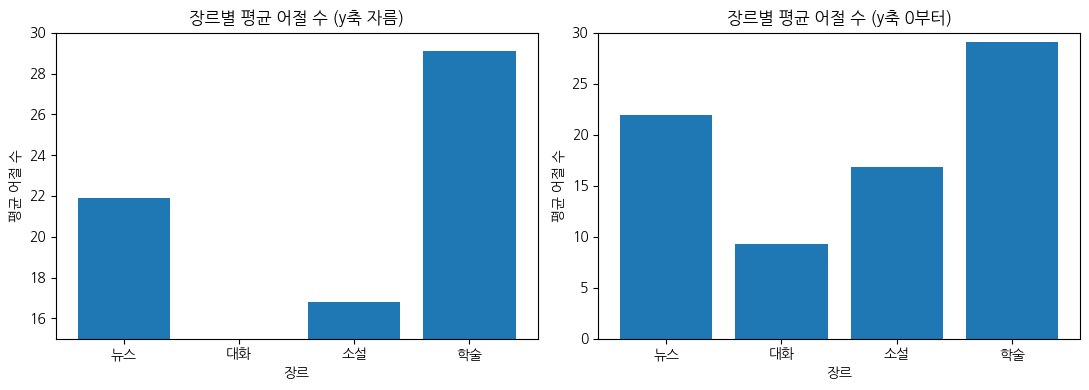

In [14]:
# (b) - (1)
def plot_yaxis_trap(texts: pd.DataFrame) -> None:
    mean_words = texts.groupby('장르')['어절수'].mean()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar(mean_words.index, mean_words.values)
    axes[0].set_ylim(15, 30)
    axes[0].set_title('장르별 평균 어절 수 (y축 자름)')
    axes[0].set_xlabel('장르')
    axes[0].set_ylabel('평균 어절 수')

    axes[1].bar(mean_words.index, mean_words.values)
    axes[1].set_ylim(0, 30)
    axes[1].set_title('장르별 평균 어절 수 (y축 0부터)')
    axes[1].set_xlabel('장르')
    axes[1].set_ylabel('평균 어절 수')

    fig.tight_layout()
    plt.show()

plot_yaxis_trap(texts)

(b) - (2)
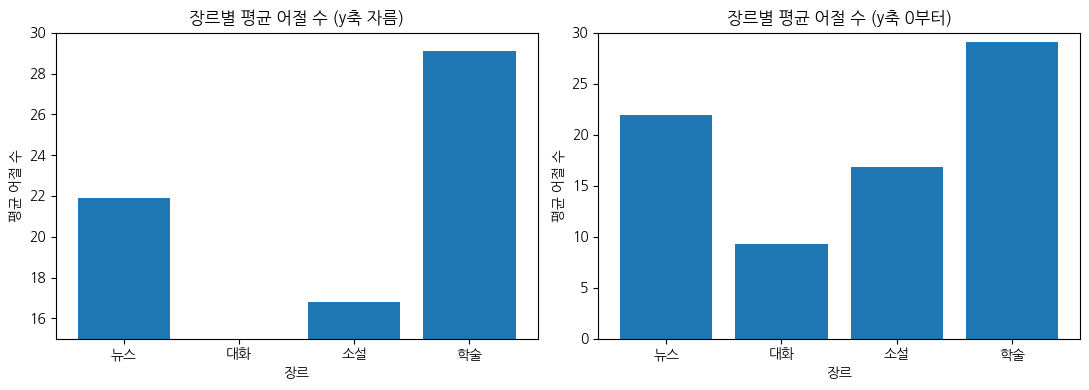
(b) - (3)
동일한 mean_words 데이터를 두 번 그리되, 왼쪽은 set_ylim(15, 30)으로 y축 하단을 잘라내고 오른쪽은 set_ylim(0, 30)으로 0부터 시작하였다. 코드 차이는 set_ylim의 첫 번째 인자 하나뿐이지만 그래프가 주는 인상이 크게 달라지는 것을 보여 준다.
서술: y축을 15부터 자른 왼쪽 그래프는 대화와 학술의 차이가 실제보다 훨씬 크게 보여 장르 간 격차를 과장한다. 막대 그래프는 막대의 길이 자체로 크기를 표현하기 때문에 y축이 0에서 출발하지 않으면 길이 비율이 왜곡되어 독자를 오도할 수 있으므로, 반드시 0부터 그려야 한다.

참고한 생성형 ai: https://claude.ai/share/34163552-09d9-44da-b6d8-f36d83346acb